In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sbn 
import numpy as np
#% matplotlib notebook


In [2]:
data=pd.read_csv('train_bank.csv')
#data_t=pd.read_csv('test_bank.csv')
#data_test=data_t.copy()
databank=data.copy()
pd.set_option('Display.max_columns',data.shape[0])
databank

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
#sbn.boxplot(x='Loan_Status',y='ApplicantIncome',data=databank)
print('le dataset contient {} lignes et {} colonnes'.format(databank.shape[0],databank.shape[1]))
#les valeurs manquantes
databank.isna().sum()

le dataset contient 614 lignes et 13 colonnes


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
databank.drop(columns='Loan_ID',axis=0,inplace=True)

In [5]:
# fonction d'encodage 
def encodage(dataframe):
    dictionnaire={'Male':0,'Female':1,'No':0,'Yes':1,'Graduate':1,'Not':0,'Urban':0,'Rural':1,'Semiurban':2,'Y':1,'N':0}
    for col in dataframe.select_dtypes('object'):
        #if col=='Dependents':
        #dataframe[col]=dataframe[col].astype('category').cat.codes
        #dataframe[col]=dataframe[col].map(dictionnaire)
        dataframe[col]=dataframe[col].astype('category').cat.codes
    return dataframe
encodage(databank)
#for col in data.select_dtypes('object'):
#    print(col)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [6]:
databank

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [7]:
numerique=list(databank[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']].columns)
categorielle=list(databank.drop(columns=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term'],
                                axis=0).columns)
categorielle=categorielle[:-1]

In [8]:
numerique

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Imputation
1. dropna
   - score f1: 53
2. remplacer les cat par le plus frequent et num par la moyenne is c'est une distribution normale, KN, ou par mediam
   - score f1:
3. feature selection 
   - score f1: 

#data_test.drop(columns='Loan_ID',axis=0,inplace=True)
# la Fonction D'imputation
def imputation(dataframe):
    dataframe=encodage(dataframe)
    #dataframe.dropna(axis=0,inplace=True)
    return dataframe

def imputation_2(dataframe):
    dataframe=encodage(dataframe)
    #dataframe.dropna(axis=0,inplace=True)
    return dataframe
#imputation(databank)

In [9]:
#data['Gender'].astype('category').cat.codes
def preproccessing(dataframe):
    #dataframe=imputation(dataframe)
    x,y=dataframe.drop(columns='Loan_Status'),dataframe['Loan_Status']
    return x,y

x,y=preproccessing(databank)
databank.dtypes

Gender                  int8
Married                 int8
Dependents              int8
Education               int8
Self_Employed           int8
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area           int8
Loan_Status             int8
dtype: object

In [10]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,2
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2


In [11]:
y

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int8

In [12]:
from sklearn.model_selection import train_test_split, validation_curve,learning_curve,ShuffleSplit,KFold,StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report,f1_score
from sklearn.neighbors import KNeighborsClassifier
import sklearn
#develloppons differebts model de classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer,SimpleImputer

In [13]:
# liste de modele 
transformer=RobustScaler()
# la dexieme imputation 
num_pipeline=make_pipeline(SimpleImputer(fill_value=np.nan,strategy='mean'))
cat_pipeline=make_pipeline (SimpleImputer(fill_value=np.nan,strategy='most_frequent'))
#modele=make_pipeline(transformer,SGDClassifier(random_state=10))
selector=make_column_transformer((num_pipeline,numerique),(cat_pipeline,categorielle))
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=10,train_size=0.7)
#print(x_train.columns, categorielle + numerique,sep='\n')
#x_train=selector.fit_transform(x_train)
#x_test=selector.transform(x_test)
modele=make_pipeline(selector,SGDClassifier(random_state=10))
x_train.shape,x_test.shape

((429, 11), (185, 11))

In [14]:
def model_Evaluation(model):
    
    model.fit(x_train,y_train)
    model.score(x_train,y_train)
    y_prediction=model.predict(x_test)
    print(y_prediction)
    print(confusion_matrix(y_test,y_prediction))
    print(classification_report(y_test,y_prediction))
    cv=ShuffleSplit(4,train_size=0.8)
    #sklearn.metrics.f1_score
    nombre_pts,trainscore,testscore=learning_curve(model,x_train,y_train,scoring= 'accuracy' ,cv=cv,
                                                   train_sizes=np.linspace(0.1,1,10))
    #print(trainscore)
    plt.figure(figsize=(8,8))
    plt.title('Evolution de score selon la quantite de donnee fournit')
    plt.plot(nombre_pts,trainscore.mean(axis=1),label='trainscore')
    plt.plot(nombre_pts,testscore.mean(axis=1),label='testscore')
    plt.legend()
    plt.show()

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[  0  52]
 [  0 133]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        52
           1       0.72      1.00      0.84       133

    accuracy                           0.72       185
   macro avg       0.36      0.50      0.42       185
weighted avg       0.52      0.72      0.60       185



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


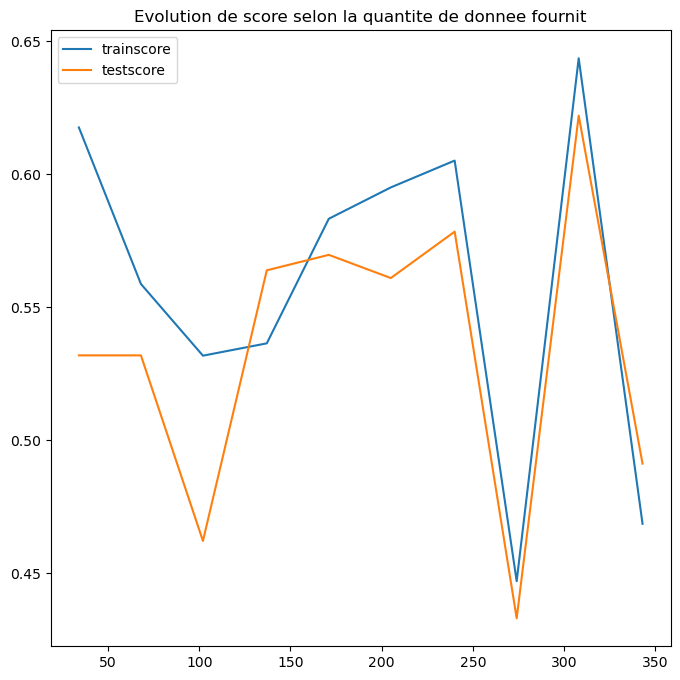

In [15]:
model_Evaluation(modele)

In [16]:
y_test.value_counts()

Loan_Status
1    133
0     52
Name: count, dtype: int64

In [17]:
dataset=data[data.LoanAmount.isna()==True].drop(columns=['Loan_ID','Loan_Status'])
dataset

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
35,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban
63,Male,Yes,1,Graduate,No,4945,0.0,NaN,360.0,0.0,Rural
81,Male,Yes,1,Graduate,Yes,2395,0.0,NaN,360.0,1.0,Semiurban
95,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban
102,Male,Yes,NaN,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban
103,Male,Yes,0,Graduate,No,4652,3583.0,NaN,360.0,1.0,Semiurban
113,Female,No,1,Graduate,Yes,7451,0.0,NaN,360.0,1.0,Semiurban
127,Male,No,0,Graduate,No,3865,1640.0,NaN,360.0,1.0,Rural
202,Male,Yes,3+,Not Graduate,No,3992,0.0,NaN,180.0,1.0,Urban


In [18]:
pd.DataFrame(data=selector.fit_transform(dataset),index=dataset.index)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['LoanAmount']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


,0,1,2,3,4,5,6,7,8,9
0,5849.0,0.0,360.0,Male,No,0,Graduate,No,1.0,Urban
35,2275.0,2067.0,360.0,Male,Yes,0,Graduate,No,1.0,Urban
63,4945.0,0.0,360.0,Male,Yes,1,Graduate,No,0.0,Rural
81,2395.0,0.0,360.0,Male,Yes,1,Graduate,Yes,1.0,Semiurban
95,6782.0,0.0,360.0,Male,No,0,Graduate,No,1.0,Urban
102,13650.0,0.0,360.0,Male,Yes,0,Graduate,No,1.0,Urban
103,4652.0,3583.0,360.0,Male,Yes,0,Graduate,No,1.0,Semiurban
113,7451.0,0.0,360.0,Female,No,1,Graduate,Yes,1.0,Semiurban
127,3865.0,1640.0,360.0,Male,No,0,Graduate,No,1.0,Rural
202,3992.0,0.0,180.0,Male,Yes,3+,Not Graduate,No,1.0,Urban
